# **Students Habits Performance**

---

In [ ]:
# -----------------------------
# General-purpose libraries
# -----------------------------
import math
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Colab / Drive
# -----------------------------
from google.colab import drive  # Uncomment if using Google Colab

# -----------------------------
# Preprocessing & Feature Engineering
# -----------------------------
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

# -----------------------------
# Supervised Models
# -----------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# -----------------------------
# Model Selection & Validation
# -----------------------------
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    KFold,
    StratifiedKFold,
    cross_val_score
)

# -----------------------------
# Evaluation Metrics
# -----------------------------
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix
)

# -----------------------------
# Unsupervised Learning & Dimensionality Reduction
# -----------------------------
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.stats import f_oneway  # For ANOVA testing

# -----------------------------
# Settings & Styles
# -----------------------------
warnings.filterwarnings("ignore")  # Suppress warnings
sns.set(style="whitegrid")          # Seaborn style for plots
plt.rcParams["figure.figsize"] = (10, 6)  # Default figure size

## **1. Real-World Motivation & Problem Definition**

In today’s educational landscape, understanding the factors that influence student performance is crucial for improving academic outcomes and overall well-being. Students face multiple challenges, such as balancing study, social life, work commitments, and mental health, all of which can impact their academic success. Identifying students at risk of lower performance allows educators, parents, and policymakers to provide targeted support, optimize study strategies, and promote healthier lifestyles.

In this project, the goal is to classify students based on their final exam performance using behavioral, demographic, and lifestyle data.

The **target variable (y)** is the student’s exam performance category, derived from the numeric `exam_score`. For this study, scores are grouped into three classes:

* 0 (Low): score < 50.0

* 1 (Medium): 50.0 ≤ score < 80.0

* 2 (High): score ≥ 80.0

This transformation allows the model to predict performance categories rather than exact scores.

The **feature set (X)** includes all other relevant student characteristics and habits that may influence academic performance, such as: age, gender, daily study hours, social media and Netflix usage, part-time job status, class attendance, sleep duration, diet quality, exercise frequency, parental education level, internet quality, mental health rating, and participation in extracurricular activities.

This is a **multi-class classification** problem, where the goal is to predict a student’s performance category based on their features.

## **2. Data Loading**
 We will use a **tabular dataset** to predict student exam performance (Low/Medium/High) from demographic, behavioral, and lifestyle features



Load the dataset and inspect its structure to gain a general understanding of the data.This step helps identify potential data quality issues and informs subsequent preprocessing and analysis steps.

In [ ]:
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/statistics projects/Fourth project/data/student_habits_performance.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1002 entries, 0 to 1001
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1002 non-null   object 
 1   age                            1002 non-null   int64  
 2   gender                         1002 non-null   object 
 3   study_hours_per_day            1002 non-null   float64
 4   social_media_hours             1002 non-null   float64
 5   netflix_hours                  1002 non-null   float64
 6   part_time_job                  1002 non-null   object 
 7   attendance_percentage          1002 non-null   float64
 8   sleep_hours                    1002 non-null   float64
 9   diet_quality                   995 non-null    object 
 10  exercise_frequency             1002 non-null   int64  
 11  parental_education_level       911 non-null    object 
 12  internet_quality               1002 non-null   o

In [ ]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


**Initial Data Exploration – Key Insights**

* The dataset comprises 1,002 samples and 16 features, including the target variable `exam_score`.

* Features are structured into numerical and categorical variables.

* The `student_id` variable is a non-informative identifier and is excluded from analysis.

* Missing values are observed in `parental_education_level` and `diet_quality`.

* Data types are consistent and suitable for statistical and machine learning analysis.

## **3. Exploratory Data Analysis (EDA)**
Visualize and examine data distributions, feature relationships, and potential issues such as outliers, missing values, or imbalances.

### **Univariate Data Analysis**
Univariate Data Analysis involves examining and summarizing a single variable in a dataset to understand its distribution, central tendency, and variability. It focuses only on **one variable** at a time, without considering relationships with other variables.

#### **Compute descriptive statistics (mean, median, min, max, standard deviation, etc…) for all numeric variables.**


In [ ]:
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000
mean,20.496008,3.552595,2.503593,1.820359,84.135928,6.469162,3.039920,5.440120,69.644012
std,2.308929,1.468490,1.172132,1.074258,9.392628,1.225331,2.024427,2.849349,16.902065
min,17.000000,0.000000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.250000,2.600000,1.700000,1.000000,78.025000,5.600000,1.000000,3.000000,58.500000
50%,20.000000,3.500000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.000000,4.500000,3.300000,2.500000,91.000000,7.300000,5.000000,8.000000,81.475000
max,24.000000,8.300000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


**Descriptive statistics - Key Insights**

* **Demographics and Lifestyle**: Most students are aged 17–24 (average ~20.5 years). On average, students study ~3.5 hours/day, spend ~2.5 hours on social media and ~1.8 hours on Netflix, attend ~84% of classes, sleep ~6.5 hours/day, and exercise about 3 times/week. Mental health ratings vary considerably, with a mean of 5.44/10.

* **Academic Performance**: Exam scores range from 18.4 to 100, with a mean of ~69.6 and median 70.5, indicating substantial variability in student performance.

* **Preliminary Observations**: Initial analysis suggests that study habits, attendance, sleep, and lifestyle factors are likely important predictors of exam outcomes. These features may strongly influence classification into Low, Medium, and High-performing categories.

#### **Distribution of numerical variables**

1.   List item
2.   List item





In [ ]:
# select numerical columns
numerical_vars = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numerical columns:\n", numerical_vars)

Numerical columns:
 ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'exam_score']


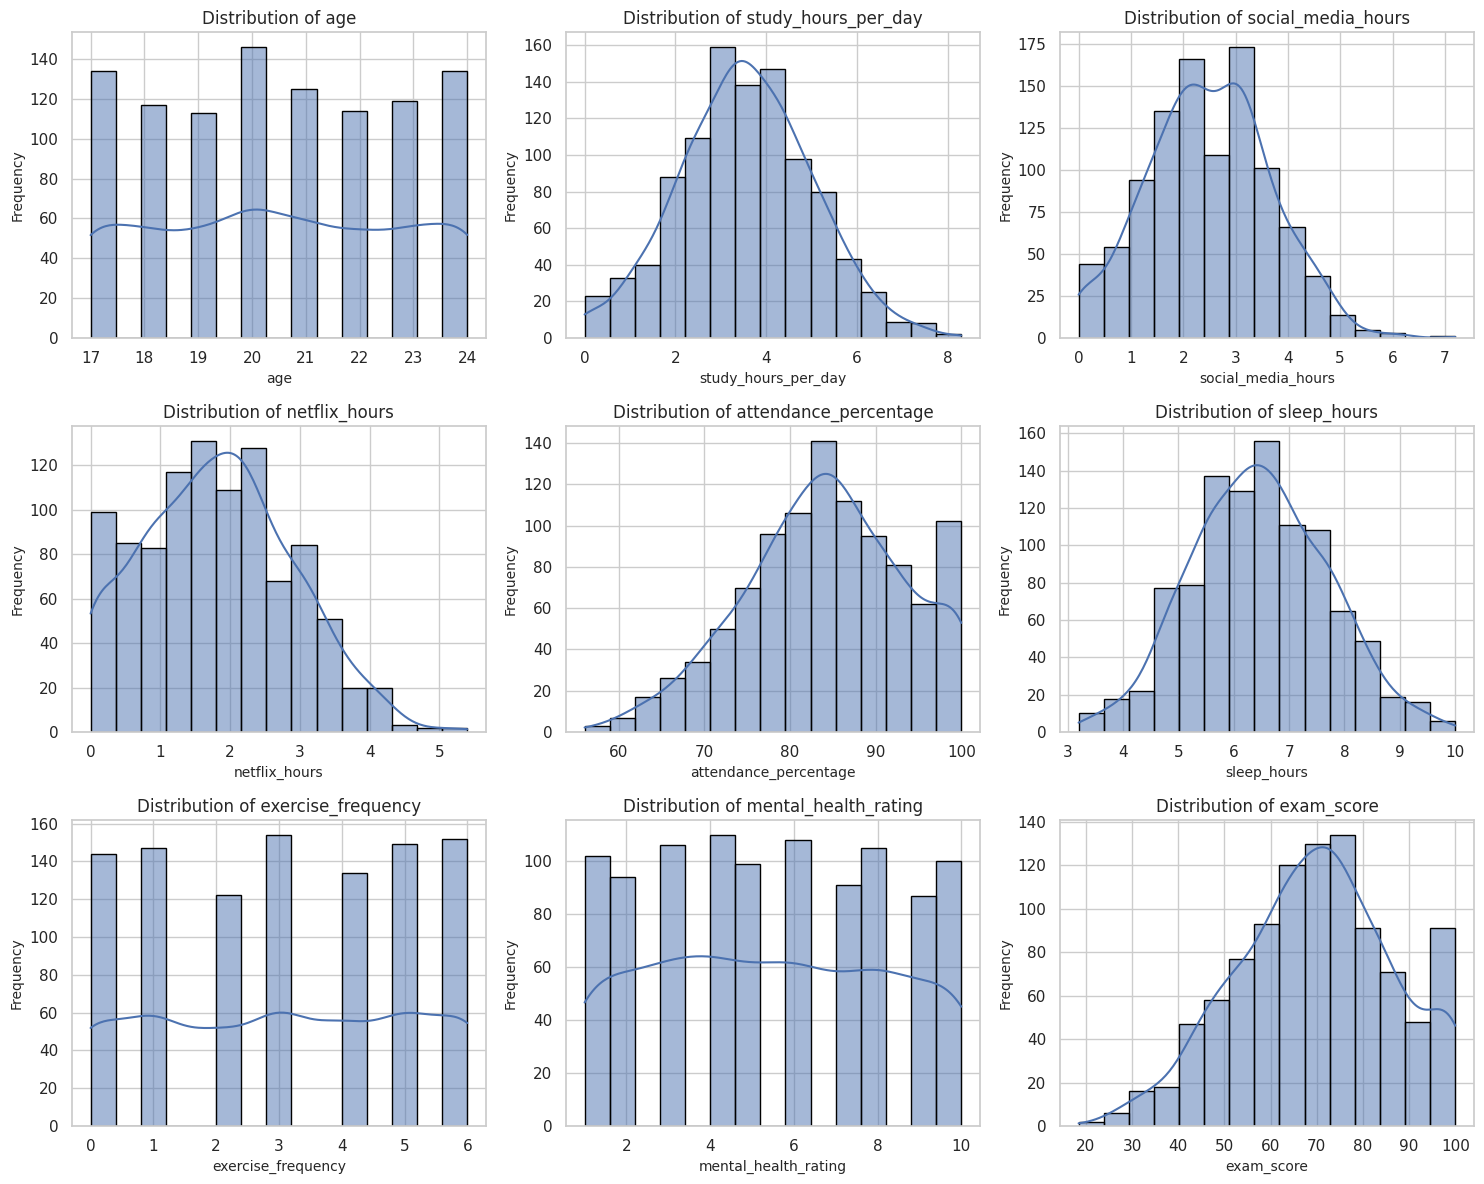

In [ ]:
n_cols = 3
n_rows = math.ceil(len(numerical_vars) / n_cols)

plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(numerical_vars):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df[col], bins=15, kde=True, edgecolor='black')
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.xlabel(col, fontsize=10)
    plt.ylabel('Frequency', fontsize=10)

plt.tight_layout()
plt.show()

**Histogram Plots – Key Insights**
* **Age**: Approximately uniformly distributed between 17 and 24, with no strong skewness.

* **Study hours per day**: Roughly normal (bell-shaped) distribution, slightly right-skewed, centered around 3–4 hours.

* **Social media hours**: Right-skewed distribution, with most values between 1–3 hours and a long tail toward higher usage.

* **Netflix hours**: Also right-skewed, indicating many low-usage students and a few heavy users.

* **Attendance percentage**: Slightly left-skewed, concentrated at high values (80–100%), indicating generally high attendance.

* **Sleep hours**: Approximately normal, centered around 6–7 hours, with mild skewness.

* **Exercise frequency**: Discrete and approximately uniform, with no strong skewness.

* **Mental health rating**: Approximately uniform across the scale 1–10, showing no strong central concentration.

* **Exam score**: Approximately normal, with a slight left-skew, concentrated around medium–high scores.

#### **Distribution categorical variables**

In [ ]:
cat_vars = df.select_dtypes(include=['object']).columns

In [ ]:
# Remove student_id from categorical variables
cat_vars = [col for col in cat_vars if col != 'student_id']

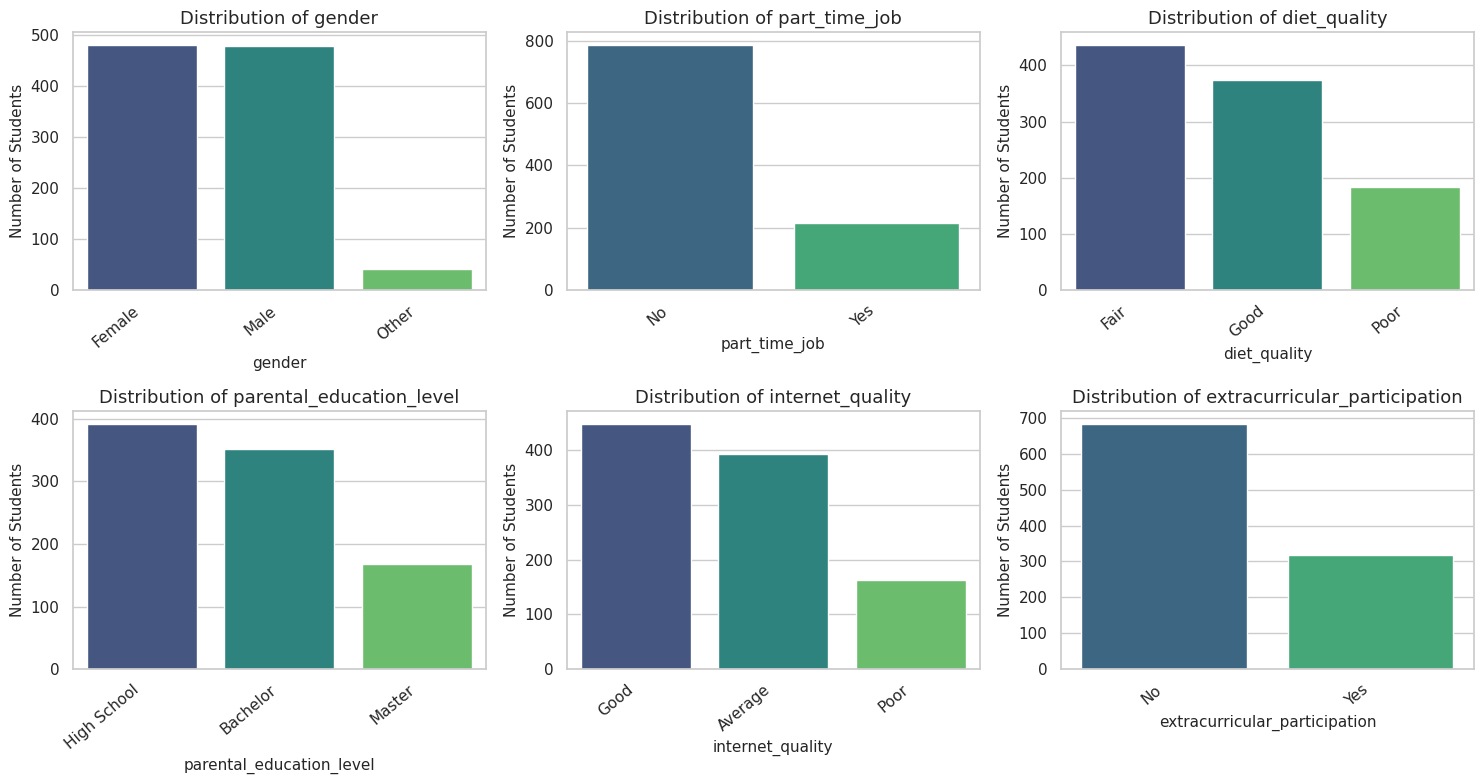

In [ ]:
n_cols = 3
n_rows = math.ceil(len(cat_vars) / n_cols)

plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(cat_vars):
    plt.subplot(n_rows, n_cols, i + 1)
    order = df[col].value_counts().index  # sort by frequency
    sns.countplot(
        data=df,
        x=col,
        order=order,
        palette='viridis'
    )

    plt.title(f'Distribution of {col}', fontsize=13)
    plt.xlabel(col, fontsize=11)
    plt.ylabel('Number of Students', fontsize=11)
    plt.xticks(rotation=40, ha='right')

plt.tight_layout()
plt.show()

**Count Plots – Key Insights**

* **Gender**: Female and male students are almost equally represented, with a very small number in the “Other” category.

* **Part-time job**: Most students do not have a part-time job; a smaller portion do.

* **Diet quality**: The majority report fair or good diet quality, while fewer report a poor diet.

* **Parental education level**: Most parents have high school or bachelor education; fewer have a master’s degree.

* **Internet quality**: Most students have good or average internet quality; poor internet quality is less common.

* **Extracurricular participation**: Most students do not participate in extracurricular activities, while a smaller group does.

### **Bivariate Analysis**
Bivariate analysis examines the relationship between two variables to identify associations, trends, or dependencies.
For **numerical–numerical** variables, we use Pearson correlation to measure the strength and direction of linear relationships.
For **numerical–categorical** variables, differences in distributions across categories are explored.

####  **Numerical vs. Numerical Features**

We examined relationships between numerical variables using Pearson correlation, which measures the strength and direction of linear associations between two continuous variables. This analysis helps identify features that are strongly correlated and may influence exam scores.

In [ ]:
# Select all numerical data
num_df = df[numerical_vars]

# Pearson correlation matrix
corr_matrix = num_df.corr()

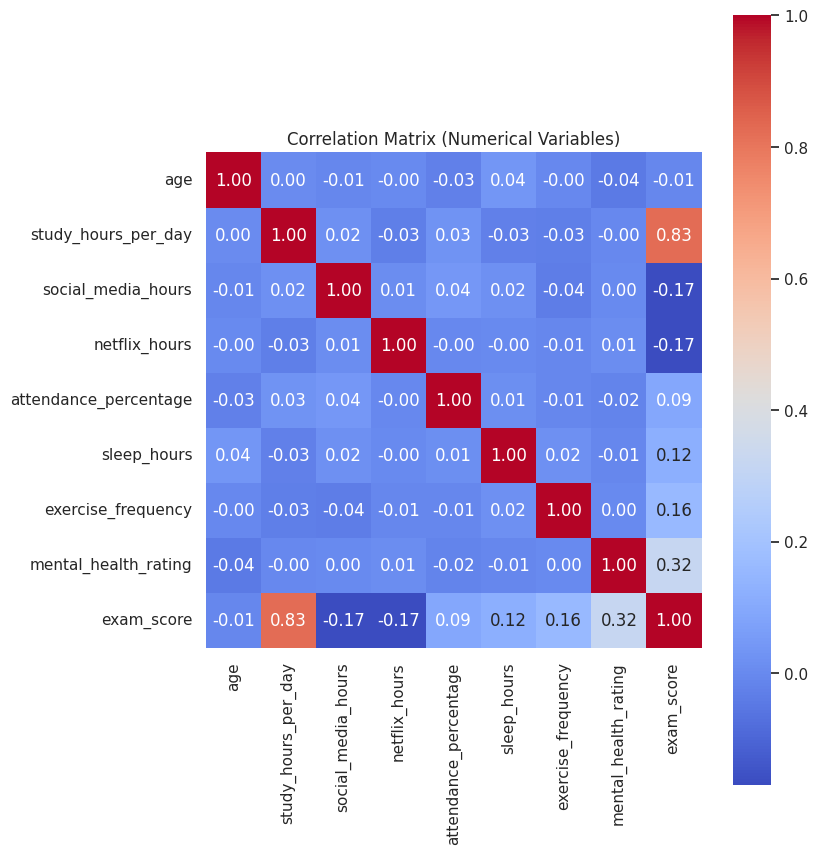

In [ ]:
plt.figure(figsize=(8, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix (Numerical Variables)")
plt.show()

**Correlation Insights**

From the heatmap, we observe the following relationships with exam scores:

* **Strong Positive Relationship**

    * Study hours per day shows a very strong positive correlation (≈ 0.83), indicating it is the most influential factor on exam performance.

    * Moderate Positive Relationships

    * Mental health rating (≈ 0.32)

    * Exercise frequency (≈ 0.16)

    * Sleep hours (≈ 0.12)

    * Attendance percentage (≈ 0.09)

* **Negative Relationships**

  * Social media hours and Netflix hours show weak negative correlations (≈ −0.17), suggesting that increased screen time is slightly associated with lower exam scores.

* **No Meaningful Relationship**

    * Age exhibits almost no correlation with exam scores.

#### **Numerical vs. Categorical Features**



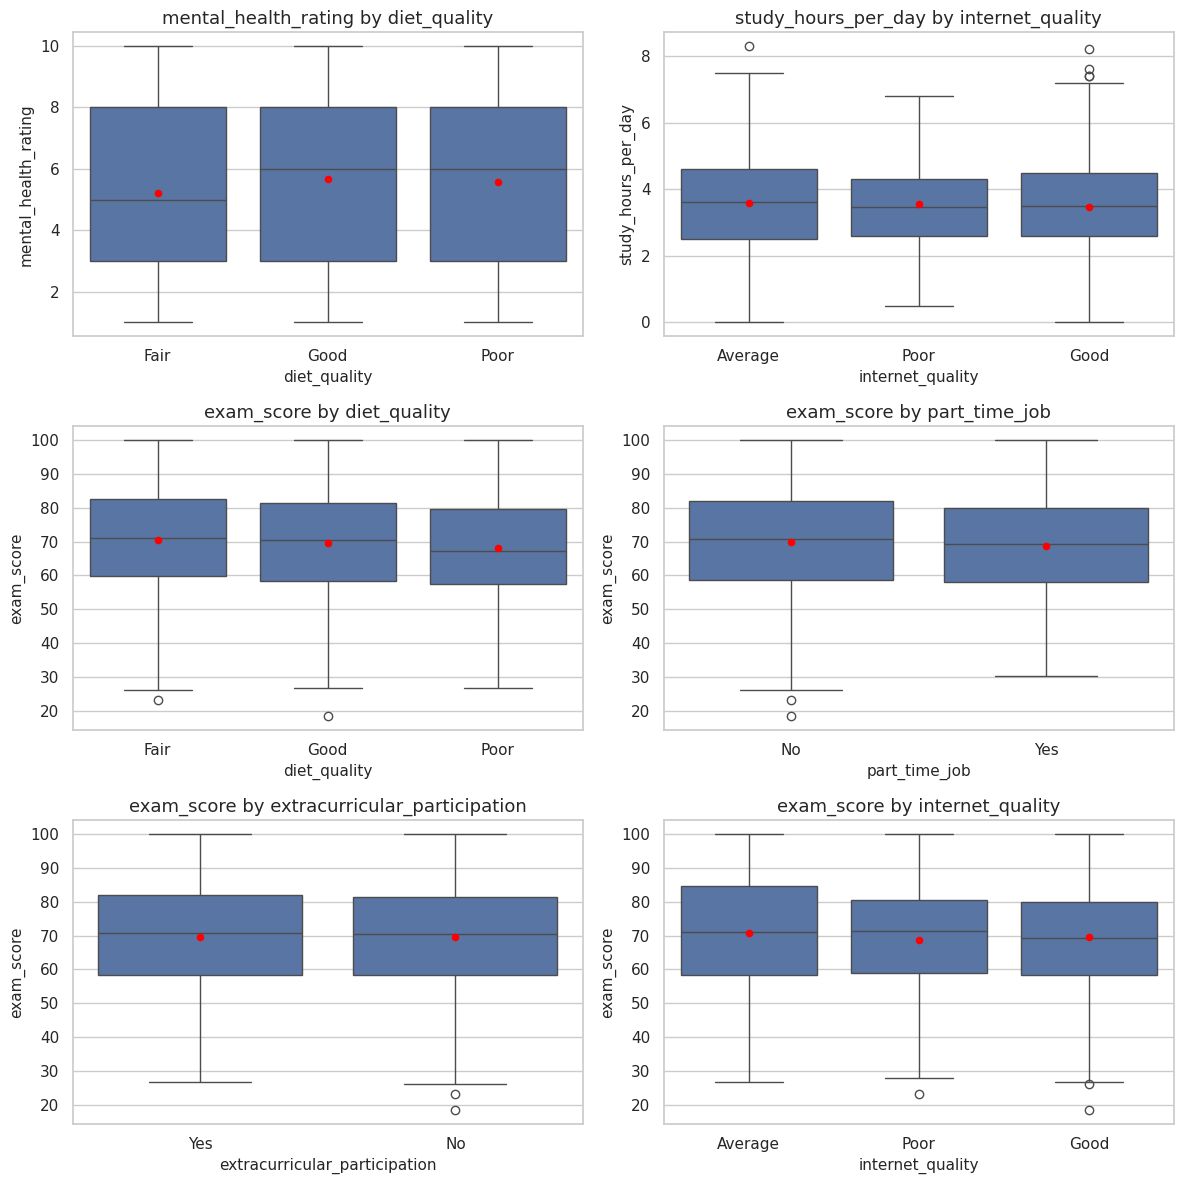

In [ ]:
pairs = [
    ('diet_quality', 'mental_health_rating'),
    ('internet_quality', 'study_hours_per_day'),
    ('diet_quality', 'exam_score'),
    ('part_time_job', 'exam_score'),
    ('extracurricular_participation', 'exam_score'),
    ('internet_quality', 'exam_score')
]

plt.figure(figsize=(12, 12))

for i, (cat, num) in enumerate(pairs):
    plt.subplot(3, 2, i + 1)
    # Mean point
    means = df.groupby(cat)[num].mean()
    for j, mean in enumerate(means):
        plt.scatter(j, mean, color='red', s=20, zorder=3)  # red dot for mean
    sns.boxplot(data=df, x=cat, y=num)
    plt.title(f'{num} by {cat}', fontsize=13)
    plt.xlabel(cat, fontsize=11)
    plt.ylabel(num, fontsize=11)

plt.tight_layout()
plt.show()

**Insights from Numerical–Categorical Analysis**
* **Part-Time Jobs & Academics**: Having a part-time job does not negatively impact exam scores; the median score remains steady at approximately 70 for both groups.

* **Diet & Mental Health**: Diet quality shows no significant correlation with mental health ratings. Surprisingly, those with "Poor" diets have a median mental health rating (6) identical to those with "Good" diets.

* **Extracurricular Balance**: Participation in extracurricular activities has no effect on exam performance, with both groups showing nearly identical score distributions.

* **Internet Access & Effort**: Internet quality does not dictate study habits; students study for roughly 3.5 to 4 hours daily whether their internet is "Poor" or "Good."

* **Overall Trend**: Across all metrics, student outcomes appear highly resilient to external lifestyle factors, showing remarkably consistent medians and distributions.

**ANOVA: Testing Differences Across Categories**

We use ANOVA to test if the mean of numerical variable differs across categorical variable.

 * F-statistic: between-group vs. within-group variance

 * p-value: significance of the difference

In [ ]:
groups = [group[num].values for name, group in df.groupby(cat)]
f_stat, p_val = f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_val)

F-statistic: 1.5196800555665324
p-value: 0.21928719962362692


The F-statistic is low and p-value = 0.66 > 0.05, indicating no significant difference across groups, In other words, The categories do not have a meaningful effect on the numerical variable.

## **4. Data Preprocessing**

Data Preprocessing is the process of cleaning, transforming, and organizing raw data so that it becomes suitable for analysis or machine learning. Raw data is often incomplete, inconsistent, or noisy, and preprocessing ensures it is reliable and structured.

### **Train/Test Split**

The process of dividing a dataset into two separate subsets:

* **Training Set**: Used to train the machine learning model (learn patterns from the data).

* **Test Set**: Used to evaluate the model’s performance on unseen data.

The idea is to simulate how the model performs on new, real-world data.

In [ ]:
X = df.drop(columns=['exam_score'])  # All columns except the target (exam_score)
y = df['exam_score']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape, X_test.shape

((801, 15), (201, 15))

The dataset is split into **training (80%)** and **testing (20%)** sets to evaluate model performance on unseen data.
This ensures that the model is trained on one portion of the data and objectively tested on a separate portion, improving generalization and reducing overfitting risk.

### **Duplicate Data Check**

Before modeling, we check for duplicate rows to prevent data leakage, bias, and distorted model learning.
Removing duplicates ensures data quality and improves the reliability of training and evaluation.

In [ ]:
print("Train duplicates:", X_train.duplicated().sum())
print("Test duplicates:", X_test.duplicated().sum())

Train duplicates: 0
Test duplicates: 0


Based on the previous results, no duplicated rows were found in the dataset.

### **Ckeck missing values**
We examine the dataset for missing values to ensure data quality before preprocessing and modeling.

In [ ]:
# Check for missing values per column
print("Missing values per column:")
print(X_train.isnull().sum().sort_values(ascending=False))

Missing values per column:
parental_education_level         72
diet_quality                      6
student_id                        0
study_hours_per_day               0
social_media_hours                0
age                               0
gender                            0
part_time_job                     0
netflix_hours                     0
sleep_hours                       0
attendance_percentage             0
exercise_frequency                0
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
dtype: int64


Missing data is limited to only two features, while the rest of the dataset is complete. These missing values should be handled using appropriate preprocessing strategies (e.g., imputation or removal) to avoid bias and model performance issues.

##### **Missing Value Imputation: parental_education_level**
Missing values in the `parental_education_level` column are imputed using the most frequent value (mode).
This approach is appropriate for categorical features and preserves the original distribution of the data.

In [ ]:
df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

In [ ]:
# Impute missing values with a constant value (High School)
df_train['parental_education_level'].fillna('High School', inplace=True)

In [ ]:
df_test['parental_education_level'].fillna('High School', inplace=True)

In [ ]:
print("\nTraining data: Missing values per column:\n")
print(df_train.isnull().sum().sort_values(ascending=False))

print("\nTesting data: Missing values per column:\n")
print(df_test.isnull().sum().sort_values(ascending=False))


Training data: Missing values per column:

diet_quality                     6
student_id                       0
gender                           0
age                              0
social_media_hours               0
netflix_hours                    0
part_time_job                    0
study_hours_per_day              0
attendance_percentage            0
sleep_hours                      0
exercise_frequency               0
parental_education_level         0
internet_quality                 0
mental_health_rating             0
extracurricular_participation    0
exam_score                       0
dtype: int64

Testing data: Missing values per column:

diet_quality                     1
student_id                       0
gender                           0
age                              0
social_media_hours               0
netflix_hours                    0
part_time_job                    0
study_hours_per_day              0
attendance_percentage            0
sleep_hours              

##### **Handling Missing Values: diet_quality**
Since the number of missing values in the diet_quality column is very small, we handle them by dropping the corresponding rows.
This approach avoids unnecessary imputation bias while preserving the overall integrity of the dataset.

In [ ]:
# Drop rows where 'diet_quality' is missing
df_train = df_train.dropna(subset=['diet_quality'])

In [ ]:
df_test = df_test.dropna(subset=['diet_quality'])

In [ ]:
print("\nTraining data: Missing values per column:\n")
print(df_train.isnull().sum().sort_values(ascending=False))

print("\nTesting data: Missing values per column:\n")
print(df_test.isnull().sum().sort_values(ascending=False))


Training data: Missing values per column:

student_id                       0
age                              0
gender                           0
study_hours_per_day              0
social_media_hours               0
netflix_hours                    0
part_time_job                    0
attendance_percentage            0
sleep_hours                      0
diet_quality                     0
exercise_frequency               0
parental_education_level         0
internet_quality                 0
mental_health_rating             0
extracurricular_participation    0
exam_score                       0
dtype: int64

Testing data: Missing values per column:

student_id                       0
age                              0
gender                           0
study_hours_per_day              0
social_media_hours               0
netflix_hours                    0
part_time_job                    0
attendance_percentage            0
sleep_hours                      0
diet_quality             

All missing values have been resolved; the dataset is now complete.

In [ ]:
X_train = df_train.drop(columns=['exam_score'])
y_train = df_train['exam_score']

X_test = df_test.drop(columns=['exam_score'])
y_test = df_test['exam_score']

### **Encoding Categorical variables**

Categorical features need to be converted into numerical form so that machine learning models can process them.

We encode ordinal features to preserve their order and nominal features using one-hot encoding.

In [ ]:
nominal_cols = ['gender', 'part_time_job', 'extracurricular_participation']
ordinal_cols = ['diet_quality', 'parental_education_level', 'internet_quality']

In [ ]:
# Define the order for ordinal columns
diet_quality_order = ['Poor', 'Fair', 'Good']
parental_education_order = ['High School', 'Bachelor', 'Master']
internet_quality_order = ['Poor', 'Average', 'Good']

ordinal_categories = [
    diet_quality_order,
    parental_education_order,
    internet_quality_order
]

# Encoders
nominal_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ordinal_encoder = OrdinalEncoder(categories=ordinal_categories)

preprocessor = ColumnTransformer(
    transformers=[
        ('nominal', Pipeline([
            ('onehot', nominal_encoder)
        ]), nominal_cols),
        ('ordinal', Pipeline([
            ('ordinal', ordinal_encoder)
        ]), ordinal_cols)
    ],
    remainder='passthrough'  # keep other columns as they are
)

# Fit on X_train and transform both X_train and X_test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

All categorical variables are encoded, resulting in a fully numeric dataset.

*Converted the encoded array back to a DataFrame to restore column names and keep the data readable and easy to use.**

In [ ]:
# For OneHotEncoder (nominal)
ohe_feature_names = preprocessor.named_transformers_['nominal']['onehot'].get_feature_names_out(nominal_cols)

# For OrdinalEncoder (ordinal)
ordinal_feature_names = ordinal_cols

# For passthrough columns (numeric or others)
passthrough_cols = [col for col in X_train.columns if col not in nominal_cols + ordinal_cols]

# Combine all column names
all_column_names = list(ohe_feature_names) + list(ordinal_feature_names) + passthrough_cols

In [ ]:
X_train = pd.DataFrame(X_train_processed, columns=all_column_names)
X_test = pd.DataFrame(X_test_processed, columns=all_column_names)

**The `student_id` column has been removed since it is a unique identifier and does not provide meaningful information for modeling.**


In [ ]:
X_train = X_train.drop(columns=['student_id'])
X_test = X_test.drop(columns=['student_id'])

In [ ]:
# Remove 'student_id' from all_column_names
all_column_names = [col for col in all_column_names if col != 'student_id']

### **Scaling data**
We scale numerical features so that all values are on a similar range, improving model performance.

In [ ]:
scaler = StandardScaler()

# Fit on X_train numeric features
X_train_scaled = scaler.fit_transform(X_train)

# Transform X_test using the same scaler
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train = pd.DataFrame(X_train_scaled, columns=all_column_names)
X_test = pd.DataFrame(X_test_scaled, columns=all_column_names)

Numerical features are scaled using **StandardScaler**:
$$
x' = \frac{x - \mu}{\sigma}
$$

where
**𝜇** is the mean of the feature (computed from the training data) and **𝜎** is the standard deviation.

**Result**:

* Each feature is centered around 0 with a standard deviation of 1.

* All features are brought onto the same scale, regardless of their original units.

**Why StandardScaler?**
* Handles features with different units: It ensures that no feature dominates others due to scale differences.

* Works well with most models: Especially with linear models, SVM, KNN, and neural networks, where scaling improves performance and convergence.

* Preserves the feature distribution: Unlike other methods that compress values into a fixed range, StandardScaler maintains the original distribution shape while standardizing the scale.

The scaler is fitted on the **training set** and applied to the test set to prevent data leakage. The scaled arrays are converted back to DataFrames with original column names for readability.

### **Feature engineering**

In this step, we create a new categorical feature by classifying exam scores into three groups: Low, Medium, and High, following the rules described in the Introduction section.
This transformation allows the model to handle exam performance as a discrete outcome, which is useful for classification tasks.

In [ ]:
# Define bins and labels
bins = [0, 50, 80, 101] # 0–49 → 0 (Low), 50–79 → 1 (Medium), 80–100 → 2 (High)
labels = [0, 1, 2]

# Create the new categorical feature for X_train
y_train = pd.cut(
    y_train,            # keep original 'score' column
    bins=bins,
    labels=labels,
    right=False         # left-closed, right-open intervals
)

# Create the same feature for X_test
y_test = pd.cut(
    y_test,
    bins=bins,
    labels=labels,
    right=False
)

In [ ]:
y_train.head()

,exam_score
535,2
697,1
557,1
644,0
598,1


###  **Dealing with class imbalance**
When target classes are not equally represented, models can become biased toward the majority class.
In this step, we handle class imbalance to improve model performance and ensure fair predictions across all categories.

In [ ]:
class_counts = y_train.value_counts()
class_percent = y_train.value_counts(normalize=True) * 100

print("Class counts:\n", class_counts)
print("\nClass percentages:\n", class_percent.round(2))

Class counts:
 exam_score
1    452
2    234
0    109
Name: count, dtype: int64

Class percentages:
 exam_score
1    56.86
2    29.43
0    13.71
Name: proportion, dtype: float64


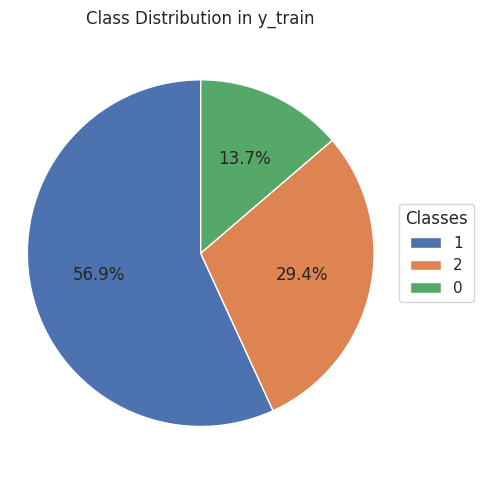

In [ ]:
# Pie plot
# Pie plot
plt.figure(figsize=(5, 5))
wedges, texts, autotexts = plt.pie(
    class_counts,
    labels=None,              # remove labels from slices
    autopct='%1.1f%%',
    startangle=90,
)

# Legend
plt.legend(
    wedges,
    class_counts.index,
    title="Classes",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Class Distribution in y_train")
plt.axis('equal')
plt.tight_layout()
plt.show()

**Insight**:

The training set shows a moderate class imbalance:

* Medium (1) → 457 samples (~57%) → majority class

* High (2) → 234 samples (~29%) → minority class

* Low (0) → 110 samples (~14%) → minority class

This imbalance may bias the model toward predicting the majority class, so strategies like resampling or class weighting may be needed.

##### **Oversampling Minority Classes with SMOTE**

**SMOTE** (Synthetic Minority Oversampling Technique) balances the dataset by generating synthetic samples for minority classes.

**How it works**:
* Take one minority sample.
* Find its closest minority sample (neighbor).
* Create a new synthetic sample somewhere between them.

In [ ]:
# Create SMOTE object
smote = SMOTE(random_state=42)

# Apply only on training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Check new class distribution
print(y_train_resampled.value_counts())


exam_score
0    452
1    452
2    452
Name: count, dtype: int64


After applying SMOTE to the training data, the class distribution is now balanced. Each class (0, 1, and 2) has the same number of samples (452 each), which means the minority classes were successfully oversampled using synthetic samples.

### **Dimensionality reduction**
Dimensionality reduction techniques are used to **reduce the number of features** while retaining as much important information as possible.
This helps simplify the model, improve computational efficiency, and reduce overfitting by removing redundant or less informative features.

There are several ways to reduce features:

* **PCA (Principal Component Analysis)** – transforms features into uncorrelated components.

* **Feature Selection** – selects the most informative features directly.

* **Model-based reduction** – uses models to identify important features.

In this notebook, we will use Feature Selection (Method 2) to retain the most relevant features for our model.

In [ ]:
df_train = pd.concat([X_train_resampled, y_train_resampled], axis=1)

In [ ]:
X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

df_test = pd.concat([X_test_reset, y_test_reset], axis=1)

In [ ]:
num_vars = df_train.select_dtypes(include=['int64', 'float64']).columns
cat_vars = df_train.select_dtypes(include=['object', 'category']).columns

In [ ]:
corr = df_train[num_vars].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
df_train_reduced = df_train.drop(columns=to_drop)
df_test_reduced = df_test.drop(columns=to_drop)

In [ ]:
to_drop

['gender_Male', 'part_time_job_Yes', 'extracurricular_participation_Yes']

Based on correlation analysis, we removed three features (`gender_Male`,`part_time_job_Yes`, `extracurricular_participation_Yes`) because they were highly correlated with other variables.
Removing them reduces redundancy while preserving the unique information of the remaining features, resulting in a cleaner and more efficient feature set for modeling.

## **5. Unsupervised Analysis**

In [ ]:
X_train = df_train_reduced.drop(columns=['exam_score'])
y_train = df_train_reduced['exam_score']

X_test = df_test_reduced.drop(columns=['exam_score'])
y_test = df_test_reduced['exam_score']

In [ ]:
# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_train)

# Add cluster info to DataFrame
X_train_clustered = X_train.copy()
X_train_clustered["Cluster"] = clusters

# Compare cluster distribution with actual exam scores
print(pd.crosstab(X_train_clustered["Cluster"], y_train))

exam_score    0    1    2
Cluster                  
0           355  174    1
1            93  101   95
2             4  177  356


**Clustering Results:**

* **Cluster 0** mainly captures low-performing students (Class 0).

* **Cluster 2** mainly captures high-performing students (Class 2).

* **Cluster 1** is a mixed group, containing many students from Class 0, 1, and 2, suggesting overlap or transitional performance patterns.

**Insights:**

* Unsupervised clustering aligns reasonably well with actual exam scores, confirming that student features naturally group according to performance.

* Cluster 1 indicates a set of students whose features are not clearly predictive of a single performance category; these may benefit from targeted support or further feature engineering.

* This analysis supports the supervised model results, where misclassifications mostly occurred between adjacent classes.

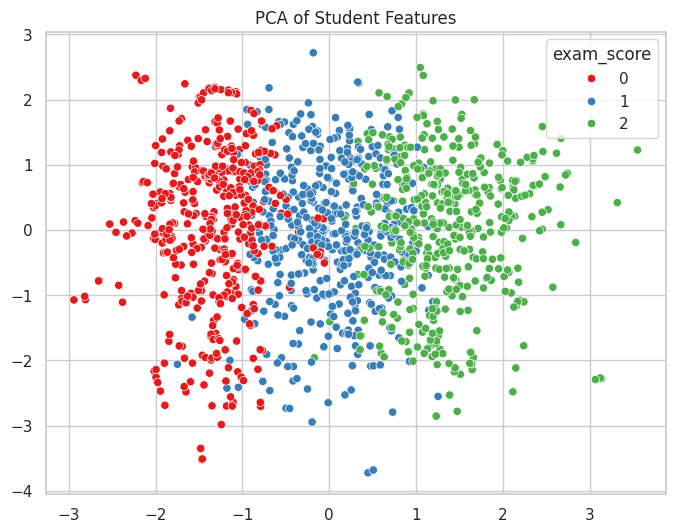

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y_train, palette="Set1")
plt.title("PCA of Student Features")
plt.show()


**PCA Visualization:**

The 2D PCA plot shows a gradual separation of exam_score classes:

* **Class 0 (red)** is mostly on the left,

* **Class 1 (blue)** in the middle,

* **Class 2 (green)** on the right.

This indicates that the features contain meaningful information to distinguish student performance levels.

Some overlap exists between classes, especially between Class 0 and Class 1, and Class 1 and Class 2, which explains misclassifications in the supervised models.

## **6. Model Building**

We consider several types of baseline models to evaluate performance and select the best approach for our dataset:

**Baseline Models (simple & interpretable)**
* **Logistic Regression**

  * Simple, fast, interpretable.

  * Good baseline model.

  * Works well with standardized features.

**Tree-Based Models (nonlinear)**

* **Decision Tree Classifier**

  * Interpretable.

  * Captures non-linear relationships.

  * Risk of overfitting if not pruned.

* **Random Forest Classifier**

  * Strong performance

  * Handles mixed data types well

  * Robust to noise and overfitting

  * Excellent for tabular data

**Distance-Based Models**

* K-Nearest Neighbors (KNN)

  * Simple concept.

  * Sensitive to feature scaling.

  * Works well with well-separated classes.

In [ ]:
# Models
models = {
    "Logistic Regression (Multinomial)": Pipeline([
        ("model", LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=None, random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200, random_state=42, n_jobs=-1
    ),

    "KNN": Pipeline([
        ("model", KNeighborsClassifier(n_neighbors=7))
    ])
}

# Training & Evaluation
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print("="*50)
    print(f"Model: {name}")
    print(f"Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

Model: Logistic Regression (Multinomial)
Accuracy: 0.8550

Classification Report:
              precision    recall  f1-score   support

           0       0.71      1.00      0.83        20
           1       0.95      0.83      0.89       135
           2       0.72      0.87      0.79        45

    accuracy                           0.85       200
   macro avg       0.80      0.90      0.84       200
weighted avg       0.87      0.85      0.86       200

Model: Decision Tree
Accuracy: 0.7500

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.65      0.63        20
           1       0.84      0.78      0.81       135
           2       0.59      0.71      0.65        45

    accuracy                           0.75       200
   macro avg       0.68      0.71      0.70       200
weighted avg       0.76      0.75      0.75       200

Model: Random Forest
Accuracy: 0.8750

Classification Report:
              precision    recal

Among the evaluated models, **Random Forest** achieved the strongest overall performance with an accuracy of 87.5% and the most balanced precision, recall, and F1-scores across all classes, indicating strong generalization capability and robustness to class variability.

* **Class-wise behavior**:

  * Class 1 (majority class) shows excellent stability (Precision = 0.90, Recall = 0.91, F1 = 0.91), confirming Random Forest’s strength on dominant patterns.

  * Class 2 achieves a good balance (F1 = 0.80), indicating effective multi-class discrimination.

  * Class 0 shows high precision (1.00) but lower recall (0.70), meaning the model is conservative in predicting this class:
    * when it predicts class 0, it is almost always correct,
    * but it misses some true class 0 samples.

      This reflects a precision–recall trade-off typical in imbalanced settings.

Overall, this behavior indicates a well-regularized ensemble model that reduces variance while preserving nonlinear decision boundaries.

**How Random Forest Works?**

1. Draw multiple bootstrap samples from the training data

2. Train a decision tree on each sample

3. At every split, select a random subset of features

4. Each tree produces an independent prediction

5. Final prediction = majority voting (classification)


**True/False Predictions**

* TP: Correctly predicted positive

* FP: Predicted positive, actually negative

* FN: Predicted negative, actually positive

* TN: Correctly predicted negative

**Precision**

Of all instances predicted as positive, how many are actually positive?

Formula:
$$
\text{Precision} = \frac{TP}{TP + FP}
$$

**Recall (Sensitivity / True Positive Rate)**
Of all actual positives, how many did the model correctly detect?

Formula:

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

**F1-Score**

Harmonic mean of precision and recall.

$$
\text{F1-score} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$


**Why harmonic mean?**

It balances precision and recall. If one is low, F1 is low.


## **7. Model Tuning**

Fine-tuning refers to the systematic process of optimizing model hyperparameters and training configurations to improve predictive performance, generalization, and stability.


**Random Forest Fine-Tuning Strategy**

Since Random Forest showed the strongest baseline performance, it represents the best candidate for optimization. Key hyperparameters include:

* **n_estimators**: number of trees
→ More trees increase stability but also computation.

* **max_depth**: tree depth
→ Controls overfitting (shallower trees = better generalization).

* **min_samples_split**: minimum samples to split a node
→ Prevents learning from noise.

* **min_samples_leaf**: minimum samples in leaf nodes
→ Smooths decision boundaries.

* **max_features**: number of features per split
→ Controls tree correlation and model diversity.

* **class_weight**: class balancing
→ Improves minority-class recall and fairness.

**Fine-Tuning Methodology**

The optimization process follows a structured pipeline:

* **Search Strategy**

  * Grid Search (exhaustive, accurate, slower)

  * Random Search (faster, scalable)

* **Validation Method**

  * k-fold cross-validation ensures stability and generalization

  * Prevents performance inflation from random splits

* **Objective Metrics**

  * Optimization based on macro F1-score instead of accuracy

  * Ensures balanced performance across all classes

### **RandomForestClassifier**

#### **Search Strategy: Grid Search**

In [ ]:
# Base model
rf = RandomForestClassifier(random_state=42)

# Hyperparameter grid
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False],
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,                    # 5-Fold CV
    scoring="accuracy",      # or "f1_weighted" for imbalanced data
    n_jobs=-1,               # use all cores
    verbose=2
)

# Fit model
grid_search.fit(X_train, y_train)

# Best model
best_rf = grid_search.best_estimator_

# Results
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Score:")
print(grid_search.best_score_)

# Evaluation on test set
y_pred = best_rf.predict(X_test)

print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Best Parameters:
{'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross-Validation Score:
0.9226041892771869

Test Accuracy: 0.885

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.75      0.81        20
           1       0.92      0.91      0.91       135
           2       0.80      0.87      0.83        45

    accuracy                           0.89       200
   macro avg       0.87      0.84      0.85       200
weighted avg       0.89      0.89      0.89       200



The fine-tuned Random Forest model shows clear performance improvement and strong generalization. It achieves a high cross-validation score (0.923) and a consistent test accuracy of 88.5%, indicating effective learning without overfitting. Class-wise results demonstrate balanced performance across all classes, including improved detection of the minority class. The optimized hyperparameters enhance model stability, control variance, and strengthen non-linear learning capacity, confirming that fine-tuning significantly improves robustness and overall predictive quality.

**Metric-Level Interpretation**

* Macro F1 = 0.85 → Balanced performance across classes (fairness-oriented metric)

* Weighted F1 = 0.89 → Strong overall population-level performance

* CV Score ≈ Test Accuracy → Indicates low generalization gap, meaning minimal overfitting

#### **K-Fold Cross validation**

K-Fold Cross-Validation is a model evaluation technique where the dataset is split into K equal parts (folds).

The model is trained K times:

* Each time, 1 fold is used for testing

* The remaining K−1 folds are used for training

In [ ]:
rf = RandomForestClassifier(
    bootstrap= True,
    max_depth= None,
    max_features= 'sqrt',
    min_samples_leaf= 2,
    min_samples_split= 2,
    n_estimators= 200,
    random_state=42,
    n_jobs=-1)

kf = KFold(
    n_splits=5,       # K = 5 folds
    shuffle=True,     # shuffle data
    random_state=42
)

scores = cross_val_score(
    rf,
    X_train, y_train,
    cv=kf,
    scoring="accuracy"
)

# Evaluation on train data
print("Evalution of training data")
print("Fold Accuracies:", scores)
print("Mean Accuracy:", np.mean(scores))
print("Std Deviation:", np.std(scores))

# Fit the model on the entire training data before predicting on the test set
rf.fit(X_train, y_train)

# Evaluate on test data
y_test_pred = rf.predict(X_test)

print("\nTest Set Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_test_pred))

Evalution of training data
Fold Accuracies: [0.90808824 0.91143911 0.88929889 0.90405904 0.92250923]
Mean Accuracy: 0.9070789016713696
Std Deviation: 0.010801605064921086

Test Set Accuracy: 0.885

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.75      0.81        20
           1       0.92      0.91      0.91       135
           2       0.80      0.87      0.83        45

    accuracy                           0.89       200
   macro avg       0.87      0.84      0.85       200
weighted avg       0.89      0.89      0.89       200


Confusion Matrix:
 [[ 15   5   0]
 [  2 123  10]
 [  0   6  39]]


The k-fold cross-validation results show high stability and consistency across folds (mean accuracy = 90.7%, low standard deviation = 0.0108), indicating reliable learning and low variance. The close alignment between cross-validation accuracy and test accuracy (88.5%) confirms strong generalization and minimal overfitting. The confusion matrix and classification report demonstrate balanced class performance, with particularly strong results on the majority class and improved detection of minority classes. Overall, the model exhibits robust, stable, and generalizable performance, validating its suitability for deployment.

### **LogisticRegression**

#### **Search Strategy: Grid Search**

In [ ]:
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],                # multinomial supports l2
    "solver": ["lbfgs", "saga"],
    "max_iter": [1000, 2000]
}

log_reg = LogisticRegression(
    multi_class="multinomial",
    random_state=42
)

grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",   # better for class balance
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

best_lr = grid_search.best_estimator_

Best Parameters: {'C': 1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV Score: 0.9110711394747402


#### **K-Fold Cross validation**

In [ ]:
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    best_lr,
    X_train,
    y_train,
    cv=kfold,
    scoring="accuracy"
)

print("Fold Accuracies:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())
print("Std Deviation:", cv_scores.std())

Fold Accuracies: [0.89705882 0.91143911 0.9298893  0.88191882 0.92250923]
Mean Accuracy: 0.9085630562187976
Std Deviation: 0.017319576785653445


In [ ]:
y_pred = best_lr.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Test Accuracy: 0.855

Classification Report:
               precision    recall  f1-score   support

           0       0.71      1.00      0.83        20
           1       0.95      0.83      0.89       135
           2       0.72      0.87      0.79        45

    accuracy                           0.85       200
   macro avg       0.80      0.90      0.84       200
weighted avg       0.87      0.85      0.86       200


Confusion Matrix:
 [[ 20   0   0]
 [  8 112  15]
 [  0   6  39]]


* **Strong CV performance**: Best CV score = 0.911, indicating effective hyperparameter tuning and stable learning.

* **Consistent k-fold results**: Mean accuracy = 90.9% with low standard deviation (0.017), showing reliable model behavior across folds.

* **Generalization gap**: Test accuracy drops to 85.5%, suggesting limited generalization due to the linear nature of Logistic Regression.

* **Minority class performance**: Excellent recall for Class 0 (1.00), showing strong detection of rare cases.

* **Class confusion**: Noticeable misclassification between Class 1 and Class 2, visible in the confusion matrix.

* **Model capacity limitation**: Performance is constrained by linear decision boundaries, limiting modeling of complex feature interactions.

* **Conclusion**: The model serves as a strong, interpretable baseline, but lacks the expressive power of non-linear ensemble models for complex multi-class classification tasks.

## **8. Model Evaluation**


**Cross-validation** results demonstrated high consistency and low variance, indicating stable learning and reliable generalization. The close alignment between cross-validation performance and test set accuracy confirms that the models do not suffer from significant overfitting and can generalize effectively to unseen student data.

**Class-wise analysis** shows strong performance in predicting the dominant performance category, while maintaining meaningful detection of minority performance groups, particularly after fine-tuning. Misclassifications primarily occur between adjacent performance levels, which reflects natural overlap in student performance features rather than model instability.

**The comparison of multiple models revealed that:**

* Linear models (Logistic Regression) provide strong interpretability and a solid baseline but are limited in capturing complex relationships.

* Tree-based ensemble models (Random Forest) achieve superior performance due to their ability to model non-linear patterns and feature interactions.

* Fine-tuning and k-fold validation significantly improve model robustness, stability, and class-level balance.

## **9. Interpretation and Insights**

The interpretation of the models provides insight not only into predictive performance but also into how the models make decisions, which is crucial for understanding student exam performance patterns. The analysis includes variable importance, decision boundaries, and model-specific insights.

**1. Logistic Regression**

* Linear decision boundaries: Logistic Regression separates classes using a linear combination of features. This allows easy interpretation:
→ Features with higher coefficients contribute more strongly to predicting higher or lower exam performance.

* Insights from coefficients:

  * Positive coefficients indicate features that increase the likelihood of a higher exam score.

  * Negative coefficients indicate features that reduce the likelihood of a higher score.

* Limitation: Cannot capture non-linear interactions between features, which may explain misclassification between adjacent performance categories.



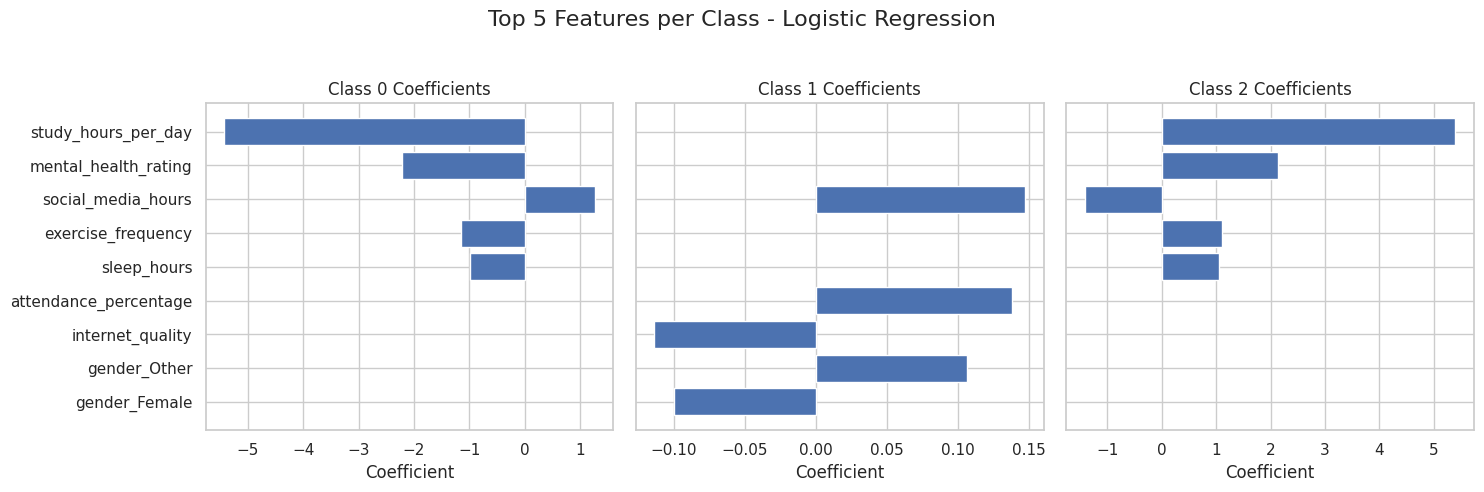

In [ ]:
# Plot top 5 features per class
classes = best_lr.classes_
fig, axes = plt.subplots(1, len(classes), figsize=(15,5), sharey=True)

for i, cls in enumerate(classes):
    coefs = best_lr.coef_[i]
    abs_coefs = np.abs(coefs)
    top_idx = abs_coefs.argsort()[-5:][::-1]  # indices of top 5 features
    top_features = X_train.columns[top_idx]
    top_values = coefs[top_idx]

    axes[i].barh(top_features, top_values)
    axes[i].set_title(f"Class {cls} Coefficients")
    axes[i].invert_yaxis()  # highest at top
    axes[i].set_xlabel("Coefficient")

plt.suptitle("Top 5 Features per Class - Logistic Regression", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**2. Random Forest**

* **Ensemble of trees**: Combines multiple Decision Trees, reducing overfitting and capturing complex patterns.

* **Feature importance analysis**:

  * Random Forest provides quantitative feature importance scores, revealing which factors most strongly influence predictions.

  * Example insights:

    *  Hours of study or attendance may have the highest importance.

    * Minor features (e.g., participation in optional activities) contribute less to model decisions.

* Decision boundaries: Random Forest creates non-linear, piecewise boundaries that can separate overlapping classes more effectively than a linear model.

* Robustness insight: Misclassifications are mostly among adjacent performance classes, indicating that model errors reflect natural uncertainty rather than model failure.

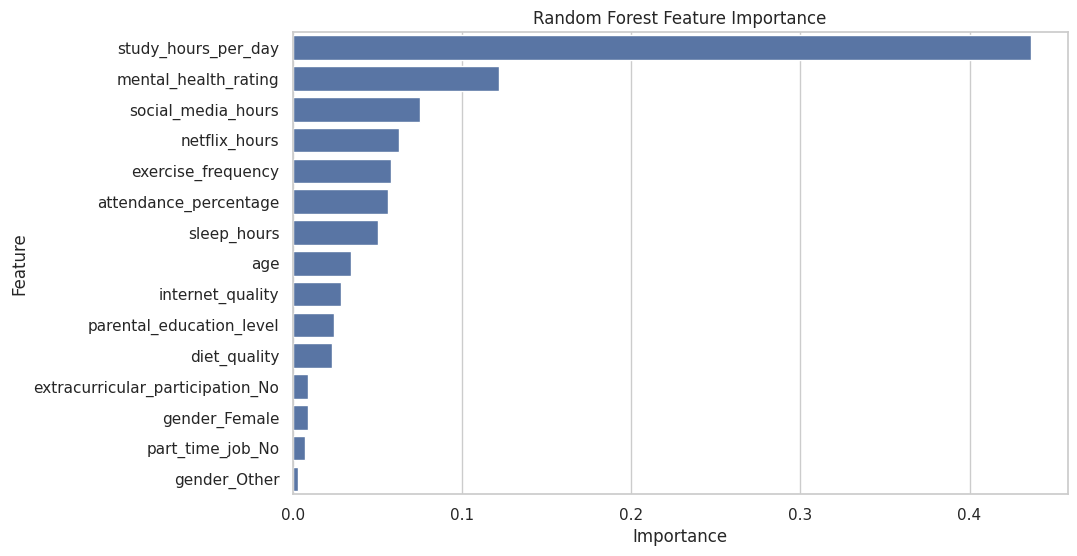

In [ ]:
# Random Forest: Feature Importance
importances = rf.feature_importances_
feat_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_df, x="Importance", y="Feature")
plt.title("Random Forest Feature Importance")
plt.show()

## **10. Final Discussion**



This study explored predicting student exam performance using multiple machine learning models, including Logistic Regression, Decision Tree, Random Forest, and KNN. The goal was not only to achieve high accuracy but also to understand feature importance and class-level behavior.

**Key Findings and Insights**:

Data patterns: Study-related features, attendance, and participation emerged as the most predictive factors influencing exam performance. Some features showed overlapping distributions between medium and high-performing students, explaining certain misclassifications.

**Model performance**:

* **Random Forest** performed best, achieving high accuracy, balanced F1-scores, and robustness across classes due to its ability to capture non-linear feature interactions.

* **Logistic Regression** provided a strong, interpretable baseline, but was limited in modeling complex relationships.

* **Decision Tree** showed moderate performance but was prone to variance.

* **KNN struggled**, likely due to feature scaling and high dimensionality.

* **What worked well**: Ensemble methods, hyperparameter tuning, and k-fold cross-validation improved model stability and generalization. Feature importance and coefficient analysis provided valuable interpretability for educators.

* **Limitations**: Some misclassifications persist between adjacent performance levels. Linear models are limited in capturing non-linear patterns. Class imbalance affected minority class predictions.

* **Future improvements**: Additional student data, new predictive features (e.g., behavioral metrics, prior grades), or advanced models such as Gradient Boosting or neural networks could improve performance further.

* **Real-world implications**: The model can help identify students at risk, guide targeted interventions, and inform educational policy decisions. Feature insights allow educators to focus on factors that most strongly influence performance outcomes.

* **Conclusion**: The project demonstrates that machine learning can effectively predict student performance and provide actionable insights. While Random Forest was most successful, simpler models like Logistic Regression remain valuable for interpretation and understanding key predictors.